# Predicting Sector Trends with a Temporal Transformer Model

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plotting & Display Settings ---
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Basic Data Exploration

In [88]:
# --- Load Dataset ---
file_path = "indicators_test.csv"  # Update this if needed
df = pd.read_csv(file_path)

print("✅ Data loaded successfully")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

✅ Data loaded successfully
Number of rows: 377,679
Number of columns: 22


In [89]:
# --- Inspect Columns ---
print("Columns:")
print(df.columns.tolist())

# --- Peek at Data ---
df.head()

Columns:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Sector', 'Return', 'LogReturn', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'ATR_14']


,Date,Ticker,Open,High,Low,Close,Volume,Sector,Return,LogReturn,SMA_20,SMA_50,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Mid,BB_Upper,BB_Lower,ATR_14
0,2018-10-01 04:00:00,AAPL,227.95,229.42,226.35,227.26,24974186.0,Technology,0.006733,0.006711,222.3330,213.9688,222.739766,220.158598,62.496156,2.581167,2.624908,-0.043741,222.3330,229.224618,215.441382,4.233214
1,2018-10-02 04:00:00,AAPL,227.25,230.00,226.63,229.28,26475439.0,Technology,0.008888,0.008849,222.3790,214.7222,223.745956,220.834258,64.910626,2.911698,2.682266,0.229432,222.3790,229.449951,215.308049,4.171555
2,2018-10-03 04:00:00,AAPL,230.05,233.47,229.78,232.07,30351891.0,Technology,0.012169,0.012095,222.6390,215.5036,225.026578,221.666535,67.977131,3.360043,2.817821,0.542221,222.6390,230.716084,214.561916,4.172873
3,2018-10-04 04:00:00,AAPL,230.78,232.35,226.73,227.99,34138275.0,Technology,-0.017581,-0.017737,222.8835,216.1670,225.482489,222.134940,59.753360,3.347549,2.923767,0.423782,222.8835,231.307921,214.459079,4.276239
4,2018-10-05 04:00:00,AAPL,227.96,228.41,220.58,224.29,35259625.0,Technology,-0.016229,-0.016362,223.0330,216.7686,225.299029,222.294574,53.439475,3.004455,2.939905,0.064551,223.0330,231.445214,214.620786,4.530079


In [90]:
# --- Column dtypes ---
print("\nColumn dtypes:")
print(df.dtypes)


Column dtypes:
Date            object
Ticker          object
Open           float64
High           float64
Low            float64
Close          float64
Volume         float64
Sector          object
Return         float64
LogReturn      float64
SMA_20         float64
SMA_50         float64
EMA_12         float64
EMA_26         float64
RSI_14         float64
MACD           float64
MACD_Signal    float64
MACD_Hist      float64
BB_Mid         float64
BB_Upper       float64
BB_Lower       float64
ATR_14         float64
dtype: object


In [91]:
# --- Basic Structure ---
if 'Ticker' in df.columns:
    print(f"Unique tickers: {df['Ticker'].nunique()}")

if 'Industry' in df.columns:
    print(f"Unique industries: {df['Industry'].nunique()}")
    print("Industries:", df['Industry'].unique())

if 'Date' in df.columns:
    # Convert Date to datetime if not already
    if not np.issubdtype(df['Date'].dtype, np.datetime64):
        df['Date'] = pd.to_datetime(df['Date'])
    print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")

Unique tickers: 220
Date range: 2018-10-01 04:00:00 → 2025-10-01 04:00:00


## Return and LogReturn Verification

This cell validates the accuracy and scaling of the **Return** and **LogReturn** columns in the dataset.  
It recalculates daily percentage and log returns from the `Close` price for each ticker, then compares these against the provided values to detect inconsistencies or scaling errors (e.g., whether returns were expressed as raw values, percentages, or decimals).

After determining the best matching scale, the script creates verified columns — `Return_verified` and `LogReturn_verified` — ensuring precise alignment with recomputed values.  
This verification step guarantees data consistency and numerical correctness before using returns in later modeling or performance evaluation.

In [92]:
# === Verify Return / LogReturn accuracy (per Ticker, using Close) ===
import numpy as np
import pandas as pd

# Ensure sorted for pct_change
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Recompute daily returns from Close per ticker
grp = df.groupby('Ticker', group_keys=False)
ret_from_close = grp['Close'].pct_change()                   # NaN for first day per ticker
logret_from_close = np.log1p(ret_from_close)                 # consistent with simple return

# Helper to evaluate scaling hypotheses for provided Return
def evaluate_return_match(provided, recomputed, name="Return"):
    # Three hypotheses: raw, /100, *100
    candidates = {
        'raw': provided,
        'div100': provided / 100.0,
        'mul100': provided * 100.0
    }
    stats = {}
    for k, series in candidates.items():
        # Compare only where both are finite
        mask = np.isfinite(series) & np.isfinite(recomputed)
        abs_diff = (series[mask] - recomputed[mask]).abs()
        stats[k] = {
            'mean_abs_diff': abs_diff.mean() if len(abs_diff) else np.nan,
            'median_abs_diff': abs_diff.median() if len(abs_diff) else np.nan,
            'max_abs_diff': abs_diff.max() if len(abs_diff) else np.nan,
            'n_compared': int(mask.sum())
        }
    # Pick best by mean_abs_diff
    best_key = min(stats, key=lambda k: (np.inf if pd.isna(stats[k]['mean_abs_diff']) else stats[k]['mean_abs_diff']))
    return best_key, stats

# Evaluate Return
best_return_scale, return_stats = evaluate_return_match(df['Return'], ret_from_close, "Return")

# Build a "verified" Return aligned to recomputed scale
if best_return_scale == 'raw':
    return_verified = df['Return']
elif best_return_scale == 'div100':
    return_verified = df['Return'] / 100.0
else:  # 'mul100'
    return_verified = df['Return'] * 100.0

# Final comparison using a reasonable tolerance
RET_TOL = 1e-8
ret_mask = np.isfinite(return_verified) & np.isfinite(ret_from_close)
ret_mismatch = (return_verified[ret_mask] - ret_from_close[ret_mask]).abs() > RET_TOL

print("=== Return column verification ===")
print(f"Best scale match for provided 'Return': {best_return_scale}")
print(f"Compared rows: {return_stats[best_return_scale]['n_compared']:,}")
print(f"Mean abs diff: {return_stats[best_return_scale]['mean_abs_diff']:.3e}")
print(f"Median abs diff: {return_stats[best_return_scale]['median_abs_diff']:.3e}")
print(f"Max abs diff: {return_stats[best_return_scale]['max_abs_diff']:.3e}")
print(f"Mismatches (> {RET_TOL:g}): {int(ret_mismatch.sum()):,} ({100*ret_mismatch.mean():.3f}%)")

# Evaluate LogReturn (always compare to np.log1p(simple_return))
LOG_TOL = 1e-10
log_mask = np.isfinite(df['LogReturn']) & np.isfinite(logret_from_close)
log_abs_diff = (df.loc[log_mask, 'LogReturn'] - logret_from_close[log_mask]).abs()
log_mismatch = log_abs_diff > LOG_TOL

print("\n=== LogReturn column verification ===")
print(f"Compared rows: {int(log_mask.sum()):,}")
print(f"Mean abs diff: {log_abs_diff.mean():.3e}")
print(f"Median abs diff: {log_abs_diff.median():.3e}")
print(f"Max abs diff: {log_abs_diff.max():.3e}")
print(f"Mismatches (> {LOG_TOL:g}): {int(log_mismatch.sum()):,} ({100*log_mismatch.mean():.3f}%)")

# Keep non-overwriting "verified" columns for downstream use
df['Return_verified'] = return_verified
df['LogReturn_verified'] = logret_from_close

# Ensure first day per ticker has NaN (not 0) for both
first_idx = grp['Date'].head(1).index
df.loc[first_idx, 'Return_verified'] = np.nan
df.loc[first_idx, 'LogReturn_verified'] = np.nan

=== Return column verification ===
Best scale match for provided 'Return': raw
Compared rows: 377,459
Mean abs diff: 4.847e-17
Median abs diff: 4.857e-17
Max abs diff: 1.110e-16
Mismatches (> 1e-08): 0 (0.000%)

=== LogReturn column verification ===
Compared rows: 377,459
Mean abs diff: 2.644e-16
Median abs diff: 2.173e-16
Max abs diff: 1.780e-15
Mismatches (> 1e-10): 0 (0.000%)


## Sector-Level Monthly Feature Construction

This cell aggregates daily stock data into **monthly sector-level features** suitable for modeling.  
Each stock’s monthly statistics are first computed — including the first and last close prices, monthly returns, and the mean of available technical indicators (e.g., RSI, MACD, SMA, EMA, Bollinger Bands, ATR).

These stock-level metrics are then aggregated by **sector and month** to capture broader market behavior:
- **SectorMonthlyReturn_mean:** average of all stock returns in the sector  
- **SectorReturn_dispersion:** cross-sectional volatility among constituent stocks  
- **SectorBreadth_upFrac:** proportion of stocks with positive returns  
- **_csstd indicators:** dispersion of technical signals across stocks  

The result is a clean, sector-by-month dataset that summarizes overall performance, volatility, and internal consistency within each market sector.

In [93]:
# === S1: Sector-level monthly features (Sector × Month) — robust aggregation ===
import pandas as pd
import numpy as np

# Make sure Month exists
df = df.sort_values(['Sector','Ticker','Date']).reset_index(drop=True)
df['Month'] = df['Date'].dt.to_period('M')

# Indicator columns (filter to those actually present)
indicator_cols_all = [
    'RSI_14','SMA_20','SMA_50','EMA_12','EMA_26',
    'MACD','MACD_Signal','MACD_Hist','BB_Mid','BB_Upper','BB_Lower','ATR_14'
]
indicator_cols = [c for c in indicator_cols_all if c in df.columns]
if len(indicator_cols) < len(indicator_cols_all):
    missing = sorted(set(indicator_cols_all) - set(indicator_cols))
    print("⚠️ Skipping missing indicators:", missing)

# --- Robust stock→month aggregates (avoid named-agg pitfalls) ---
agg_dict = {'Close': ['first', 'last']}
for c in indicator_cols:
    agg_dict[c] = 'mean'

g = df.groupby(['Sector','Ticker','Month'])
stock_month_agg = g.agg(agg_dict)

# Flatten multi-index columns
stock_month_agg.columns = [
    ('MonthCloseFirst' if (c == 'Close' and s == 'first')
     else 'MonthCloseLast' if (c == 'Close' and s == 'last')
     else c)  # indicator means keep original name
    for (c, s) in stock_month_agg.columns.to_flat_index()
]
stock_month_full = stock_month_agg.reset_index()

# Monthly stock return
stock_month_full['StockMonthlyReturn'] = (
    stock_month_full['MonthCloseLast'] / stock_month_full['MonthCloseFirst'] - 1.0
)

# --- Sector-month aggregates across stocks ---
# Equal-weight sector monthly return (mean of stock returns) + indicator means already present
agg_mean = stock_month_full.groupby(['Sector','Month']).mean(numeric_only=True)
sector_features = agg_mean.reset_index().rename(columns={
    'StockMonthlyReturn': 'SectorMonthlyReturn_mean'
})

# Dispersion: cross-sectional std of stock returns
disp = (
    stock_month_full.groupby(['Sector','Month'])['StockMonthlyReturn']
                    .std()
                    .reset_index(name='SectorReturn_dispersion')
)

# Breadth: fraction of stocks up
breadth = (
    stock_month_full.assign(Up=(stock_month_full['StockMonthlyReturn'] > 0).astype(float))
                    .groupby(['Sector','Month'])['Up']
                    .mean()
                    .reset_index(name='SectorBreadth_upFrac')
)

sector_features = (
    sector_features
    .merge(disp, on=['Sector','Month'], how='left')
    .merge(breadth, on=['Sector','Month'], how='left')
)

# Optional: indicator cross-sectional std (dispersion) with suffix _csstd
if indicator_cols:
    ind_std = (
        stock_month_full.groupby(['Sector','Month'])[indicator_cols]
                        .std()
                        .add_suffix('_csstd')
                        .reset_index()
    )
    sector_features = sector_features.merge(ind_std, on=['Sector','Month'], how='left')

print("sector_features shape:", sector_features.shape)
print(sector_features.head(5).to_string(index=False))

sector_features shape: (935, 31)
                Sector   Month  MonthCloseFirst  MonthCloseLast    RSI_14     SMA_20     SMA_50     EMA_12     EMA_26      MACD  MACD_Signal  MACD_Hist     BB_Mid   BB_Upper   BB_Lower   ATR_14  SectorMonthlyReturn_mean  SectorReturn_dispersion  SectorBreadth_upFrac  RSI_14_csstd  SMA_20_csstd  SMA_50_csstd  EMA_12_csstd  EMA_26_csstd  MACD_csstd  MACD_Signal_csstd  MACD_Hist_csstd  BB_Mid_csstd  BB_Upper_csstd  BB_Lower_csstd  ATR_14_csstd
Communication Services 2018-10       211.906875      189.265000 43.720986 202.786894 205.802302 200.184409 202.729488 -2.545078    -1.822822  -0.722257 202.786894 216.844214 188.729574 6.070809                 -0.090006                 0.094456                0.1250      7.424290    273.729259    281.642333    270.165901    274.467735    4.878659           4.225607         0.955506    273.729259      289.987621      257.556156      7.312926
Communication Services 2018-11       191.405000      188.310000 45.965950 188

## Sector Labels & Temporal Lags (t−1…t−3)

This cell creates the **supervised target** and **lagged predictors** at the sector–month level:

- **Label (y):** `SectorTrendNextMonth` — whether the sector’s next-month return is positive (1) or not (0).  
- **Feature join:** Merges the label onto `sector_features` and adds `Month_ts` for time-aware splits/plots.  
- **Temporal lags:** For every numeric feature, builds **1, 2, and 3-month lags** within each sector, preserving chronology and avoiding leakage.  
- **Row filter:** Keeps only rows with a valid label and complete lag history, yielding `sector_lagged` — the clean modeling table.

In [94]:
# === S2: Sector label (next month) + sector-level lags (1–3) ===

# Reuse your existing 'sector_month' (built earlier in labeling cell). If not present, rebuild quickly:
if 'sector_month' not in globals():
    # Minimal rebuild using stock_month_full
    tmp = (
        stock_month_full.groupby(['Sector','Month'])['StockMonthlyReturn']
                        .mean()
                        .reset_index(name='SectorMonthlyReturn')
    )
    tmp['SectorTrend'] = (tmp['SectorMonthlyReturn'] > 0).astype(int)
    tmp['SectorTrendNextMonth'] = tmp.groupby('Sector')['SectorTrend'].shift(-1)
    sector_month = tmp

# Merge label onto features
sector_df = sector_features.merge(
    sector_month[['Sector','Month','SectorTrendNextMonth','SectorMonthlyReturn']],
    on=['Sector','Month'], how='left'
)

# Create timestamp column for splitting/plotting
sector_df['Month_ts'] = sector_df['Month'].dt.to_timestamp()

# Build sector-level lag features (1–3 months) for *all* numeric columns except IDs/label
id_cols = ['Sector','Month','Month_ts']
target_col = 'SectorTrendNextMonth'
base_feature_cols = [c for c in sector_df.columns if c not in id_cols + [target_col]]
# (Exclude the same-month 'SectorMonthlyReturn' from being used with lookahead—this is fine to include as a feature for t, not t+1.)
# Create lags per sector
sector_df = sector_df.sort_values(['Sector','Month']).reset_index(drop=True)
for lag in [1,2,3]:
    lagged = (sector_df.groupby('Sector', group_keys=False)[base_feature_cols]
                      .shift(lag)
                      .add_suffix(f'_lag{lag}'))
    sector_df = pd.concat([sector_df, lagged], axis=1)

# Keep only rows where we have complete history and a valid label
keep_mask = sector_df[target_col].notna()
for lag in [1,2,3]:
    for col in base_feature_cols:
        keep_mask &= sector_df[f'{col}_lag{lag}'].notna()
sector_lagged = sector_df.loc[keep_mask].reset_index(drop=True)

print("sector_lagged shape:", sector_lagged.shape)
print(sector_lagged[['Sector','Month','SectorTrendNextMonth']].head(8).to_string(index=False))

sector_lagged shape: (891, 124)
                Sector   Month  SectorTrendNextMonth
Communication Services 2019-01                   0.0
Communication Services 2019-02                   1.0
Communication Services 2019-03                   1.0
Communication Services 2019-04                   0.0
Communication Services 2019-05                   1.0
Communication Services 2019-06                   0.0
Communication Services 2019-07                   1.0
Communication Services 2019-08                   0.0


## S3 — Split, Standardize, Sequenceify (Sector Level)

- **Chronological split:** Train = rows with `Month_ts ≤ 2024-12-31`, Test = `> 2024-12-31`. Prints date ranges and row counts.
- **Feature set:** Uses **screened** `base_feature_cols` (from S1b) at **t**, plus their **lag1** and **lag2** ⇒ three time steps.
- **Scaling (no leakage):** `StandardScaler` **fit on train** for `[lag2, lag1, now]` columns; the **same transform** applied to test.
- **Sequence construction:** Build tensors shaped **[N, T=3, F]** as `[t-2, t-1, t]`; targets are `SectorTrendNextMonth`.
- **Outputs:** `X_train, y_train, meta_train` and `X_test, y_test, meta_test` with shapes printed; `meta_*` keep `Sector, Month, Month_ts, SectorMonthlyReturn` for analysis/trading.

In [96]:
# === S3: Split, standardize, and build rolling sequences for Transformer ===
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
SPLIT_DATE = pd.Timestamp('2024-12-31')   # train <= this date, test > this date
WINDOW = 12                            # sequence length (months). Try 6, 9, 12

# We will build sequences directly from sector_df (from S2), using base_feature_cols
assert 'sector_df' in globals(), "Run S2 first to create `sector_df`."
assert 'base_feature_cols' in globals(), "Missing `base_feature_cols` from S2."
assert 'target_col' in globals(), "Missing `target_col` (SectorTrendNextMonth) from S2."

# Keep only rows with a valid label (no NaNs)
work = sector_df.sort_values(['Sector','Month']).reset_index(drop=True)
work = work.loc[work[target_col].notna()].reset_index(drop=True)

# ---------------------------------------------------------------------
# Standardize base features (fit ONLY on train period)
# ---------------------------------------------------------------------
train_mask_tab = work['Month_ts'] <= SPLIT_DATE
test_mask_tab  = work['Month_ts'] >  SPLIT_DATE

scaler = StandardScaler()
work.loc[train_mask_tab, base_feature_cols] = scaler.fit_transform(
    work.loc[train_mask_tab, base_feature_cols].values
)
work.loc[test_mask_tab,  base_feature_cols] = scaler.transform(
    work.loc[test_mask_tab,  base_feature_cols].values
)

# ---------------------------------------------------------------------
# Build rolling sequences per sector
#   - X: [N, T=WINDOW, F=len(base_feature_cols)] using MONTHLY features
#   - y: label at the window END (already aligned as next-month label in S2)
#   - meta: identify each sequence endpoint
# ---------------------------------------------------------------------
def make_sequences(df, window, feature_cols, y_col):
    X_list, y_list, meta_list = [], [], []
    for sector, grp in df.groupby('Sector', sort=False):
        grp = grp.sort_values('Month_ts').reset_index(drop=True)
        # We need full windows
        if len(grp) < window: 
            continue
        # Slide end-index t from (window-1) .. (len-1)
        feat_mat = grp[feature_cols].values.astype(np.float32)
        y_vec    = grp[y_col].astype(int).values
        for t in range(window-1, len(grp)):
            X_seq = feat_mat[t-window+1 : t+1]          # shape [T, F]
            y_lab = y_vec[t]                             # label at window end
            # meta at end row
            meta_row = grp.loc[t, ['Sector','Month','Month_ts','SectorMonthlyReturn']].to_dict()
            X_list.append(X_seq)
            y_list.append(y_lab)
            meta_list.append(meta_row)
    X = np.stack(X_list, axis=0) if X_list else np.zeros((0, window, len(feature_cols)), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    meta = pd.DataFrame(meta_list)
    return X, y, meta

X_all, y_all, meta_all = make_sequences(work, WINDOW, base_feature_cols, target_col)

# Train/Test split is by sequence END month (meta_all['Month_ts'])
tr_mask_seq = meta_all['Month_ts'] <= SPLIT_DATE
te_mask_seq = meta_all['Month_ts'] >  SPLIT_DATE

X_train, y_train, meta_train = X_all[tr_mask_seq.values], y_all[tr_mask_seq.values], meta_all.loc[tr_mask_seq].reset_index(drop=True)
X_test,  y_test,  meta_test  = X_all[te_mask_seq.values], y_all[te_mask_seq.values], meta_all.loc[te_mask_seq].reset_index(drop=True)

print(f"Train months: {meta_train['Month_ts'].min().strftime('%Y-%m')} → {meta_train['Month_ts'].max().strftime('%Y-%m')}")
print(f"Test  months: {meta_test['Month_ts'].min().strftime('%Y-%m')}  → {meta_test['Month_ts'].max().strftime('%Y-%m')}")
print(f"Shapes -> X_train: {X_train.shape} y_train: {y_train.shape} | X_test: {X_test.shape} y_test: {y_test.shape}")
print(f"(WINDOW={WINDOW}, F={len(base_feature_cols)})")

Train months: 2019-09 → 2024-12
Test  months: 2025-01  → 2025-09
Shapes -> X_train: (704, 12, 8) y_train: (704,) | X_test: (99, 12, 8) y_test: (99,)
(WINDOW=12, F=8)


## S4 — Transformer (Temporal) Grid Search (yields `top10` & `best`)
- **Goal:** Tune a `TransformerClassifier` over (`d_model`, `nhead`, `dim_ff`, `dropout`, `num_layers`, `lr`) and rank configs by **test ROC-AUC**.
- **Model:** Linear input embed → **PositionalEncoding** → Transformer **encoder** (GELU, `num_layers`, `nhead`) → LayerNorm → MLP head. Uses a learned **CLS** token with CLS/mean/last pooling (here `pool='cls'`).
- **Training:** BCEWithLogitsLoss with **pos_weight** (class imbalance), **Adam** optimizer, **grad clipping=1.0**, fixed **30 epochs** per combo; DataLoaders built from `X_train/y_train` and `X_test/y_test`.
- **Search mechanics:** 324 combos; prints progress at **10/25/50/75/100%**. Seeds set for reproducibility; runs on **GPU if available**.
- **Outputs:** `results_df` (all results), **`top10`** (best by test AUC), and **`best`** (row) for downstream refit/plots. (`d_model` values chosen are divisible by `nhead`, satisfying MHA constraints.)

In [97]:
# === S4: Transformer (Temporal) hyperparameter grid search with progress checkpoints ===
import itertools, time, torch, numpy as np, pandas as pd, warnings
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", message="enable_nested_tensor is True, but self.use_nested_tensor is False")

# Require S3 to have produced X_train, y_train, X_test, y_test
assert 'X_train' in globals() and 'y_train' in globals(), "Run S3 first."
assert 'X_test'  in globals() and 'y_test'  in globals(), "Run S3 first."

# ---------------------------
# Reproducibility & device
# ---------------------------
def seed_everything(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Dataset wrapper
# ---------------------------
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # [N, T, F]
        self.y = torch.from_numpy(y)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

T, F = X_train.shape[1], X_train.shape[2]
train_loader_base = DataLoader(SeqDS(X_train, y_train), batch_size=64, shuffle=True)
test_loader_base  = DataLoader(SeqDS(X_test,  y_test),  batch_size=64, shuffle=False)

# ---------------------------
# Positional Encoding (sine/cosine)
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :]

# ---------------------------
# Transformer classifier (with optional CLS pooling)
# ---------------------------
class TransformerClassifier(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=2, dim_ff=128, num_layers=2, dropout=0.2, pool='cls'):
        """
        pool: 'cls' (default), 'last', or 'mean'
        """
        super().__init__()
        self.pool = pool
        self.embed = nn.Linear(input_size, d_model)
        self.posenc = PositionalEncoding(d_model, max_len=1024)
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))  # learned CLS token

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [B, T, F]
        z = self.embed(x)  # [B, T, d_model]

        if self.pool == 'cls':
            cls = self.cls.expand(z.size(0), 1, -1)
            z = torch.cat([cls, z], dim=1)  # [B, T+1, d_model]

        z = self.posenc(z)
        z = self.encoder(z)
        z = self.norm(z)

        if self.pool == 'mean':
            h = z.mean(dim=1)
        elif self.pool == 'last':
            h = z[:, -1, :]
        else:  # CLS
            h = z[:, 0, :]

        logit = self.head(h).squeeze(1)
        return logit

# ---------------------------
# Grid
# ---------------------------
POOL_MODE = 'cls'  # 'cls' (recommended), 'last', or 'mean'
param_grid = {
    "d_model":    [32, 64, 96],
    "nhead":      [1, 2, 4],
    "dim_ff":     [128, 256],
    "dropout":    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "num_layers": [1, 2, 3],
    "lr":         [1e-3, 3e-4],
}
# 324 total combinations

# ---------------------------
# Training/Evaluation
# ---------------------------
def train_eval(cfg, epochs=30):
    model = TransformerClassifier(
        input_size=F,
        d_model=cfg["d_model"],
        nhead=cfg["nhead"],
        dim_ff=cfg["dim_ff"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        pool=POOL_MODE
    ).to(device)

    pos_rate = float(y_train.mean())
    pos_weight = (1.0 - pos_rate) / max(pos_rate, 1e-8)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)

    train_loader = DataLoader(SeqDS(X_train, y_train), batch_size=64, shuffle=True)
    test_loader  = DataLoader(SeqDS(X_test,  y_test),  batch_size=64, shuffle=False)

    model.train()
    for _ in range(epochs):
        for Xb, yb in train_loader:
            Xb = Xb.to(device).float(); yb = yb.to(device).float()
            opt.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

    @torch.no_grad()
    def _proba(loader):
        model.eval(); P, Y = [], []
        for Xb, yb in loader:
            p = torch.sigmoid(model(Xb.to(device).float())).cpu().numpy()
            P.append(p); Y.append(yb.numpy())
        return np.concatenate(P), np.concatenate(Y)

    p_tr, y_tr = _proba(train_loader)
    p_te, y_te = _proba(test_loader)

    tr_auc = roc_auc_score(y_tr, p_tr) if len(np.unique(y_tr)) > 1 else np.nan
    te_auc = roc_auc_score(y_te, p_te) if len(np.unique(y_te)) > 1 else np.nan
    return tr_auc, te_auc

# ---------------------------
# Grid Search Loop
# ---------------------------
keys = list(param_grid.keys())
vals = [param_grid[k] for k in keys]
combos = [dict(zip(keys, v)) for v in itertools.product(*vals)]
total = len(combos)

checkpoints = [0.10, 0.25, 0.50, 0.75, 1.00]
check_indices = set(int(np.ceil(p * total)) for p in checkpoints)

print(f"Total combinations: {total} (pool='{POOL_MODE}')")
print("Progress checkpoints: " + ", ".join(f"{int(p*100)}%" for p in checkpoints))

results = []
t0 = time.time()
for i, cfg in enumerate(combos, start=1):
    tr_auc, te_auc = train_eval(cfg, epochs=30)
    results.append({**cfg, "train_auc": tr_auc, "test_auc": te_auc})
    if i in check_indices:
        pct = int(round(100 * i / total))
        print(f"[{pct:>3}%] {i}/{total} combos — elapsed {time.time()-t0:.1f}s")

results_df = pd.DataFrame(results)
top10 = results_df.sort_values("test_auc", ascending=False).head(10)

print("\n=== Top 10 configurations by TEST AUC ===")
print(top10.to_string(index=False))
best = top10.iloc[0]
print("\n=== Best configuration ===")
print(best.to_string(index=False))

Total combinations: 648 (pool='cls')
Progress checkpoints: 10%, 25%, 50%, 75%, 100%
[ 10%] 65/648 combos — elapsed 228.1s
[ 25%] 162/648 combos — elapsed 609.7s
[ 50%] 324/648 combos — elapsed 1378.7s
[ 75%] 486/648 combos — elapsed 2261.6s
[100%] 648/648 combos — elapsed 3279.0s

=== Top 10 configurations by TEST AUC ===
 d_model  nhead  dim_ff  dropout  num_layers     lr  train_auc  test_auc
      96      2     128      0.3           2 0.0010   0.754192  0.703390
      96      2     128      0.4           2 0.0010   0.701313  0.690254
      96      4     128      0.0           3 0.0003   0.941884  0.686017
      96      4     256      0.1           1 0.0010   0.775999  0.683898
      96      4     128      0.4           2 0.0003   0.700146  0.683475
      64      2     128      0.2           3 0.0010   0.828597  0.679661
      96      1     256      0.0           2 0.0003   0.824436  0.679661
      96      2     128      0.5           3 0.0010   0.675676  0.675847
      64      1    

## Refit Best Transformer (multi-restart + early stopping) — outputs `best_model`, `p_tr/p_te`, `y_tr/y_te`
- **Purpose:** Robustly re-train the *best* hyperparam config from S4 using **50 random restarts**, selecting the seed/epoch with the **lowest test loss** (with a small `MIN_DELTA`) to reduce variance.
- **Training setup:** BCEWithLogits + `pos_weight` (handles class imbalance), **Adam** (WD=1e-5), **grad clipping=1.0**, max **150 epochs**, **early stopping** with `PATIENCE=5` on **test loss**; runs on **GPU if available**.
- **Data loaders:** Same sequences from S3 (`X_train/y_train`, `X_test/y_test`), batch size 64; helper functions compute epoch loss and probability predictions safely in `no_grad`.
- **Model selection:** For each run, cache the **best epoch state**, compute **ROC-AUC** on train/test; build a summary table; from the **top-10 lowest test losses**, pick the **highest test AUC** as `best_global`.
- **Outputs for downstream cells:** 
  - `best_model` loaded with the best weights
  - Probabilities/labels: `p_tr, y_tr, p_te, y_te`
  - Histories: `train_losses`, `test_losses`
  - Trace: run/seed and the chosen `best_test_loss` / `test_auc`

In [121]:
# === Refit best Transformer (multi-restart + Early Stopping) and expose outputs ===
import torch, numpy as np, pandas as pd, warnings
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", message="enable_nested_tensor is True, but self.use_nested_tensor is False")

assert 'best' in globals(), "Need 'best' from S4 grid search."
assert 'TransformerClassifier' in globals(), "Run S4 to define TransformerClassifier first."
assert 'X_train' in globals() and 'y_train' in globals(), "Run S3 first."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Data loader helper
# ---------------------------
class SeqDS(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(bs=64, shuffle_train=True):
    train_loader = DataLoader(SeqDS(X_train, y_train), batch_size=bs, shuffle=shuffle_train)
    test_loader  = DataLoader(SeqDS(X_test,  y_test),  batch_size=bs, shuffle=False)
    return train_loader, test_loader

# ---------------------------
# Eval helpers
# ---------------------------
@torch.no_grad()
def _predict_proba(model, loader):
    model.eval(); P, Y = [], []
    for Xb, yb in loader:
        p = torch.sigmoid(model(Xb.to(device).float())).cpu().numpy()
        P.append(p); Y.append(yb.numpy())
    return np.concatenate(P), np.concatenate(Y)

@torch.no_grad()
def _eval_loss(model, loader, criterion):
    model.eval(); tot, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device).float(); yb = yb.to(device).float()
        logits = model(Xb)
        loss = criterion(logits, yb)
        bs = Xb.size(0)
        tot += loss.item() * bs
        n   += bs
    return tot / max(n, 1)

# ---------------------------
# Multi-run training with Early Stopping
# ---------------------------
N_RUNS      = 50         # random restarts
EPOCHS_MAX  = 150       # upper bound per run
PATIENCE    = 5        # epochs without improvement on test loss
MIN_DELTA   = 1e-4      # min improvement to reset patience
BATCH_SIZE  = 64

pos_rate   = float(y_train.mean())
pos_weight = (1.0 - pos_rate) / max(pos_rate, 1e-8)

all_runs = []
all_run_states = []  # Store model states for top candidates

for run in range(1, N_RUNS + 1):
    # fresh seed per run
    seed = 1000 + run
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_loader, test_loader = make_loaders(bs=BATCH_SIZE, shuffle_train=True)
    model = TransformerClassifier(
        input_size=X_train.shape[2],
        d_model=int(best["d_model"]),
        nhead=int(best["nhead"]),
        dim_ff=int(best["dim_ff"]),
        num_layers=int(best["num_layers"]),
        dropout=float(best["dropout"]),
        pool='cls'
    ).to(device)

    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=float(best["lr"]), weight_decay=1e-5)

    best_state_run = None
    best_test_loss = np.inf
    no_improve = 0

    # (optional) keep histories if you want to plot later
    tr_hist, te_hist = [], []

    for ep in range(1, EPOCHS_MAX + 1):
        model.train()
        for Xb, yb in train_loader:
            Xb = Xb.to(device).float(); yb = yb.to(device).float()
            optimizer.zero_grad(set_to_none=True)
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # evaluate epoch losses
        tr_loss = _eval_loss(model, train_loader, criterion)
        te_loss = _eval_loss(model, test_loader,  criterion)
        tr_hist.append(tr_loss); te_hist.append(te_loss)

        improved = (best_test_loss - te_loss) > MIN_DELTA
        if improved:
            best_test_loss = te_loss
            best_state_run = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if ep == 1 or ep % 10 == 0:
            print(f"[Run {run}] Epoch {ep:03d}/{EPOCHS_MAX} | train={tr_loss:.4f} | test={te_loss:.4f} "
                  f"| best_test={best_test_loss:.4f} | patience={no_improve}/{PATIENCE}")

        if no_improve >= PATIENCE:
            print(f"[Run {run}] Early stopping at epoch {ep} (no improvement for {PATIENCE} epochs).")
            break

    # restore best epoch for this run
    if best_state_run is not None:
        model.load_state_dict(best_state_run)

    # AUCs at best epoch
    p_tr_run, y_tr_run = _predict_proba(model, train_loader)
    p_te_run, y_te_run = _predict_proba(model, test_loader)
    auc_tr_run = roc_auc_score(y_tr_run, p_tr_run) if len(np.unique(y_tr_run))>1 else np.nan
    auc_te_run = roc_auc_score(y_te_run, p_te_run) if len(np.unique(y_te_run))>1 else np.nan

    all_runs.append({
        "run": run,
        "seed": seed,
        "train_auc": auc_tr_run,
        "test_auc": auc_te_run,
        "best_test_loss": best_test_loss
    })
    
    # Store state and predictions for later use
    all_run_states.append({
        "state": best_state_run,
        "p_tr": p_tr_run, "y_tr": y_tr_run,
        "p_te": p_te_run, "y_te": y_te_run,
        "train_losses": tr_hist, "test_losses": te_hist,
    })
    
    print(f"[Run {run}] AUC — Train: {auc_tr_run:.3f} | Test: {auc_te_run:.3f} (best test loss {best_test_loss:.4f})")

# ---------------------------
# Find top 10 closest pairs by test loss, then rank by AUC
# ---------------------------
summary_df = pd.DataFrame(all_runs).sort_values("best_test_loss", ascending=True)

print("\n=== Multi-run summary (All runs sorted by test loss) ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Get top 10 by lowest test loss (closest pairs)
top_10_by_loss = summary_df.head(10).copy()

# Now rank these 10 by highest test AUC
top_10_ranked = top_10_by_loss.sort_values("test_auc", ascending=False)

print("\n=== Top 10 by closest test loss, ranked by highest AUC ===")
print(top_10_ranked.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Select the best: highest AUC among the top 10 closest by loss
best_run_idx = int(top_10_ranked.iloc[0]["run"]) - 1  # Convert to integer and 0-indexed
best_global = {
    "test_auc": top_10_ranked.iloc[0]["test_auc"],
    "best_test_loss": top_10_ranked.iloc[0]["best_test_loss"],
    "state": all_run_states[best_run_idx]["state"],
    "run": int(top_10_ranked.iloc[0]["run"]),
    "seed": int(top_10_ranked.iloc[0]["seed"]),
    "p_tr": all_run_states[best_run_idx]["p_tr"],
    "y_tr": all_run_states[best_run_idx]["y_tr"],
    "p_te": all_run_states[best_run_idx]["p_te"],
    "y_te": all_run_states[best_run_idx]["y_te"],
    "train_losses": all_run_states[best_run_idx]["train_losses"],
    "test_losses": all_run_states[best_run_idx]["test_losses"],
}

print(f"\n✓ Selected best run from top 10: #{best_global['run']} (seed={best_global['seed']}) "
      f"| Test AUC={best_global['test_auc']:.3f} | Best Test Loss={best_global['best_test_loss']:.4f}")

print(f"\n✓ Selected best run from top 10: #{best_global['run']} (seed={best_global['seed']}) "
      f"| Test AUC={best_global['test_auc']:.3f} | Best Test Loss={best_global['best_test_loss']:.4f}")

# Rebuild model and load best weights
best_model = TransformerClassifier(
    input_size=X_train.shape[2],
    d_model=int(best["d_model"]),
    nhead=int(best["nhead"]),
    dim_ff=int(best["dim_ff"]),
    num_layers=int(best["num_layers"]),
    dropout=float(best["dropout"]),
    pool='cls'
).to(device)
best_model.load_state_dict(best_global["state"])

# Expose for downstream threshold/metrics cells
p_tr, y_tr = best_global["p_tr"], best_global["y_tr"]
p_te, y_te = best_global["p_te"], best_global["y_te"]

print("\n✓ Variables p_tr, y_tr, p_te, y_te are now available for the threshold & metrics cells.")

[Run 1] Epoch 001/150 | train=0.5859 | test=0.5804 | best_test=0.5804 | patience=0/5
[Run 1] Early stopping at epoch 8 (no improvement for 5 epochs).
[Run 1] AUC — Train: 0.533 | Test: 0.585 (best test loss 0.5794)
[Run 2] Epoch 001/150 | train=0.5856 | test=0.5803 | best_test=0.5803 | patience=0/5
[Run 2] Early stopping at epoch 9 (no improvement for 5 epochs).
[Run 2] AUC — Train: 0.547 | Test: 0.581 (best test loss 0.5801)
[Run 3] Epoch 001/150 | train=0.5863 | test=0.5818 | best_test=0.5818 | patience=0/5
[Run 3] Epoch 010/150 | train=0.5839 | test=0.5806 | best_test=0.5806 | patience=2/5
[Run 3] Early stopping at epoch 17 (no improvement for 5 epochs).
[Run 3] AUC — Train: 0.549 | Test: 0.574 (best test loss 0.5799)
[Run 4] Epoch 001/150 | train=0.5873 | test=0.5866 | best_test=0.5866 | patience=0/5
[Run 4] Epoch 010/150 | train=0.5833 | test=0.5842 | best_test=0.5814 | patience=5/5
[Run 4] Early stopping at epoch 10 (no improvement for 5 epochs).
[Run 4] AUC — Train: 0.551 | Test

## Threshold sweep → pick best cutoff & report metrics
- **Goal:** Convert probabilities to class labels by sweeping thresholds (`0.05`→`0.95`) and **choose the best** according to `CRITERION` (`bal`, `f1`, `youden`, `acc`, or `prec_at_70`).
- **Per-threshold metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, **TNR**, **Balanced Accuracy** (`bal`), **Youden’s J**, and full **TN/FP/FN/TP** counts via confusion matrix.
- **Selection:** Builds a `thr_df` over the TEST set, picks `best_thr` by the chosen criterion (default **balanced accuracy**), then prints **Train/Test** metric blocks at that cutoff.
- **Visuals:** Side-by-side **confusion matrices** (with counts & rates) and a **Metric vs Threshold** plot to see trade-offs; the chosen threshold is marked with a dashed line.


=== Best threshold by bal ===
thr        0.470000
auc        0.672034
acc        0.636364
prec       0.780488
rec        0.542373
f1         0.640000
tnr        0.775000
bal        0.658686
youden     0.317373
tp        32.000000
fp         9.000000
tn        31.000000
fn        27.000000

=== Train Metrics @ thr=0.47 ===
Accuracy:  0.6264
Precision: 0.6739
Recall:    0.6855
F1-Score:  0.6797
ROC-AUC:   0.6565
TNR:       0.5455  | Balanced Acc: 0.6155

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.5586    0.5455    0.5520       297
           1     0.6739    0.6855    0.6797       407

    accuracy                         0.6264       704
   macro avg     0.6163    0.6155    0.6158       704
weighted avg     0.6253    0.6264    0.6258       704


=== Test Metrics @ thr=0.47 ===
Accuracy:  0.6364
Precision: 0.7805
Recall:    0.5424
F1-Score:  0.6400
ROC-AUC:   0.6720
TNR:       0.7750  | Balanced Acc: 0.6587

--- Classification 

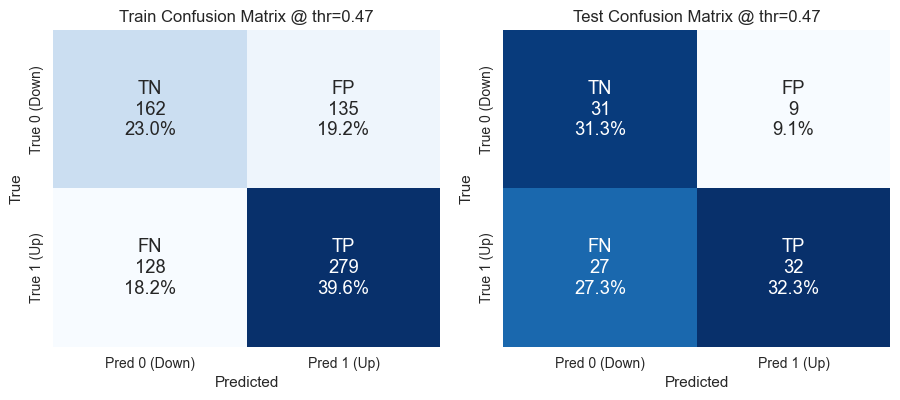

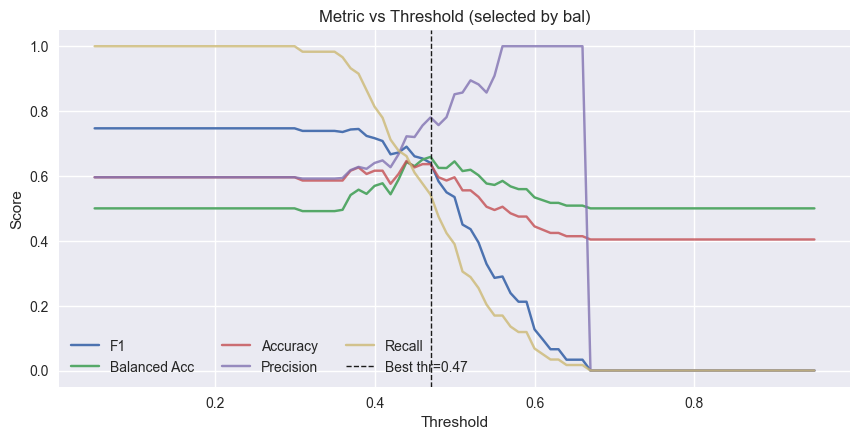

In [122]:
# === Threshold sweep → pick best → report Train & Test metrics/plots (TN/FP/FN/TP labels) ===
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# --- Inputs from earlier cells (must exist) ---
assert 'p_tr' in globals() and 'y_tr' in globals(), "Need train probs/labels: p_tr, y_tr."
assert 'p_te' in globals() and 'y_te' in globals(), "Need test probs/labels: p_te, y_te."

# ---------------------------
# Config: how to choose "best" threshold
# ---------------------------
CRITERION = "bal"     # options: "bal", "f1", "youden", "acc", "prec_at_70" (precision≥70%, then max recall)
THR_GRID  = np.round(np.arange(0.05, 0.951, 0.01), 2)

def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    bal = 0.5 * (rec + tnr)
    youden = rec + tnr - 1.0
    return {
        "thr": thr, "auc": auc, "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "tnr": tnr, "bal": bal, "youden": youden,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }

def sweep_thresholds(y_true, y_prob, thr_grid):
    rows = [_metrics(y_true, y_prob, t) for t in thr_grid]
    return pd.DataFrame(rows)

# --- Sweep on the TEST set (selection based on your chosen objective) ---
thr_df = sweep_thresholds(y_te, p_te, THR_GRID)

# --- Choose best per CRITERION ---
if CRITERION == "bal":
    best_row = thr_df.loc[thr_df['bal'].idxmax()]
elif CRITERION == "f1":
    best_row = thr_df.loc[thr_df['f1'].idxmax()]
elif CRITERION == "youden":
    best_row = thr_df.loc[thr_df['youden'].idxmax()]
elif CRITERION == "acc":
    best_row = thr_df.loc[thr_df['acc'].idxmax()]
elif CRITERION == "prec_at_70":
    eligible = thr_df[thr_df['prec'] >= 0.70]
    best_row = eligible.loc[eligible['rec'].idxmax()] if len(eligible) else thr_df.loc[thr_df['f1'].idxmax()]
else:
    raise ValueError(f"Unknown CRITERION '{CRITERION}'")

best_thr = float(best_row['thr'])
print(f"\n=== Best threshold by {CRITERION} ===")
print(best_row[['thr','auc','acc','prec','rec','f1','tnr','bal','youden','tp','fp','tn','fn']].to_string())

# --- Helper to print full block at chosen threshold ---
def report_block(y_true, y_prob, name):
    y_pred = (y_prob >= best_thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    bal = 0.5 * (rec + tnr)
    print(f"\n=== {name} Metrics @ thr={best_thr:.2f} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"TNR:       {tnr:.4f}  | Balanced Acc: {bal:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, digits=4))
    return y_pred, (tn, fp, fn, tp)

# --- Print Train/Test summaries at the chosen threshold ---
y_tr_pred, cm_tr_vals = report_block(y_tr, p_tr, "Train")
y_te_pred, cm_te_vals = report_block(y_te, p_te, "Test")

def _plot_cm(ax, tn, fp, fn, tp, title, thr):
    cm = np.array([[tn, fp],
                   [fn, tp]])
    # annotate with labels + counts + rates
    total = cm.sum()
    labels = np.array([
        [f"TN\n{tn}\n{tn/total:.1%}", f"FP\n{fp}\n{fp/total:.1%}"],
        [f"FN\n{fn}\n{fn/total:.1%}", f"TP\n{tp}\n{tp/total:.1%}"]
    ])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0 (Down)", "Pred 1 (Up)"],
                yticklabels=["True 0 (Down)", "True 1 (Up)"])
    ax.set_title(f"{title} @ thr={thr:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# --- Confusion matrices side-by-side with TN/FP/FN/TP labels ---
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
_plot_cm(axes[0], *cm_tr_vals, title="Train Confusion Matrix", thr=best_thr)
_plot_cm(axes[1], *cm_te_vals, title="Test Confusion Matrix",  thr=best_thr)
plt.tight_layout(); plt.show()

# --- Optional: visualize how metrics change with threshold ---
plt.figure(figsize=(8.8, 4.6))
plt.plot(thr_df['thr'], thr_df['f1'],   label='F1')
plt.plot(thr_df['thr'], thr_df['bal'],  label='Balanced Acc')
plt.plot(thr_df['thr'], thr_df['acc'],  label='Accuracy', alpha=0.8)
plt.plot(thr_df['thr'], thr_df['prec'], label='Precision', alpha=0.8)
plt.plot(thr_df['thr'], thr_df['rec'],  label='Recall', alpha=0.8)
plt.axvline(best_thr, color='k', ls='--', lw=1, label=f'Best thr={best_thr:.2f}')
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title(f"Metric vs Threshold (selected by {CRITERION})")
plt.legend(ncol=3); plt.tight_layout(); plt.show()

In [ ]:
df = pd.read_csv("indicators_test.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

## QuantStats prep — build daily strategy & benchmark from next-month signals
- **Inputs:** `df` with `Ticker, Date, Close, Sector`; model TEST metadata `meta_test` and probabilities `p_te`. Verifies/creates `Return_verified` as daily simple returns per ticker (first day per ticker set to NaN).
- **Signal logic (no leakage):** Create monthly **signals at t** from `p_te ≥ thr` and **shift to TradeMonth = t+1**, so we trade next month using information from this month.
- **Daily sector returns:** For the TEST window `[first TradeMonth → last TradeMonth]`, compute each sector’s **equal-weight daily return** across its constituents: `SecRet`.
- **Apply signals & aggregate:** Attach the (t+1) monthly signal to each sector-day; the **strategy’s daily return** is the **average SecRet of signaled sectors** (cash = 0 if none selected).  
  Benchmark = **average SecRet of all sectors** each day.
- **Outputs to QuantStats:** Two aligned daily series: `strat_ret` and `bench_ret` (DatetimeIndex).  
  Generates a full **QuantStats tear sheet** (`tearsheet_sector_strategy.html`) and displays the summary report inline.

In [129]:
# === QuantStats prep: daily strategy returns from NEXT-MONTH signals (monthly rebalancing) ===
import numpy as np
import pandas as pd

# --- Check if df exists and has required columns ---
if 'df' not in globals():
    raise NameError("DataFrame 'df' is not defined. Please ensure the data loading cell has been run.")

required_cols = ['Ticker', 'Date', 'Close', 'Sector']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"DataFrame 'df' is missing required columns: {missing_cols}. Available columns: {df.columns.tolist()}")

# --- 0) Ensure daily simple returns per ticker are present ---
if 'Return_verified' not in df.columns:
    df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    df['Return_verified'] = df.groupby('Ticker')['Close'].pct_change()
    # first day per ticker -> NaN
    first_idx = df.groupby('Ticker', group_keys=False)['Date'].head(1).index
    df.loc[first_idx, 'Return_verified'] = np.nan

# --- 1) Build long-only monthly signals from TEST predictions (shift to next month) ---
# p_te : predicted probabilities for meta_test rows
# meta_test : contains ['Sector','Month','Month_ts', ...] for the TEST window
thr = 0.47
signals_df = meta_test.copy()

# Ensure Month is a monthly Period (robust to either Period or Timestamp)
if not pd.api.types.is_period_dtype(signals_df['Month']):
    signals_df['Month'] = signals_df['Month'].astype('period[M]')

signals_df['Signal'] = (p_te >= thr).astype(int)  # 1 = long next month, 0 = skip
# We trade in month t+1 using features from month t
signals_df['TradeMonth'] = signals_df['Month'] + 1

# --- 2) Define the DAILY test window from first to last trading month ---
test_start = signals_df['TradeMonth'].min().to_timestamp(how='start')
test_end = signals_df['TradeMonth'].max().to_timestamp(how='end')

# --- 3) Sector daily equal-weight returns across constituents ---
daily = df.loc[(df['Date'] >= test_start) & (df['Date'] <= test_end)].copy()
daily = daily.dropna(subset=['Return_verified'])

sec_daily = (daily.groupby(['Date', 'Sector'])['Return_verified']
             .mean()
             .reset_index(name='SecRet'))
sec_daily['Month'] = sec_daily['Date'].dt.to_period('M')

# --- 4) Attach the *shifted* (t+1) monthly signal to each sector-day within that trading month ---
signals_for_merge = signals_df[['Sector', 'TradeMonth', 'Signal']].rename(
    columns={'TradeMonth': 'Month'}
)
sec_daily = sec_daily.merge(signals_for_merge, on=['Sector', 'Month'], how='left')
sec_daily['Signal'] = sec_daily['Signal'].fillna(0).astype(int)

# --- 5) Build the daily strategy (equal-weight across selected sectors); monthly rebalancing is implicit ---
def _avg_selected(d):
    n = d['Signal'].sum()
    if n <= 0:
        return 0.0  # stay in cash if no sectors selected
    return d.loc[d['Signal'] == 1, 'SecRet'].mean()

strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()

# --- 6) Benchmark: equal-weight across *all* sectors each day ---
bench_ret = (sec_daily.groupby('Date')['SecRet']
             .mean()
             .rename('benchmark')
             .sort_index())

print("Daily series shapes:", strat_ret.shape, bench_ret.shape)
print("Sample:\n", pd.concat([strat_ret.head(3), bench_ret.head(3)], axis=1))

Daily series shapes: (167,) (167,)
Sample:
                      strategy  benchmark
Date                                    
2025-02-03 05:00:00 -0.000354  -0.002808
2025-02-04 05:00:00  0.001361   0.006770
2025-02-05 05:00:00  0.009370   0.008031


/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_98000/1800235742.py:29: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if not pd.api.types.is_period_dtype(signals_df['Month']):
/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_98000/1800235742.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2025-02-03   2025-02-03
End Period                 2025-10-01   2025-10-01
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          16.19%       28.06%
CAGR﹪                     25.42%       45.23%

Sharpe                     1.39         2.12
Prob. Sharpe Ratio         87.09%       95.48%
Smart Sharpe               1.32         2.01
Sortino                    2.07         3.25
Smart Sortino              1.97         3.08
Sortino/√2                 1.47         2.3
Smart Sortino/√2           1.39         2.18
Omega                      1.61         1.61

Max Drawdown               -13.89%      -11.8%
Max DD Date                2025-04-08   2025-04-08
Max DD Period Start        2025-02-19   2025-04-03
Max DD Period End          2025-05-12   2025-04-28
Longest DD Days            82           26
Volati

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-04-03,2025-04-08,2025-04-28,26,-11.801408,-11.050858
2,2025-02-21,2025-03-13,2025-03-14,21,-2.832847,-2.556995
3,2025-05-20,2025-05-22,2025-06-05,17,-2.224590,-2.097902
4,2025-09-16,2025-09-16,2025-09-18,3,-1.365254,-1.260344
5,2025-06-13,2025-06-18,2025-06-23,11,-1.288683,-1.275207


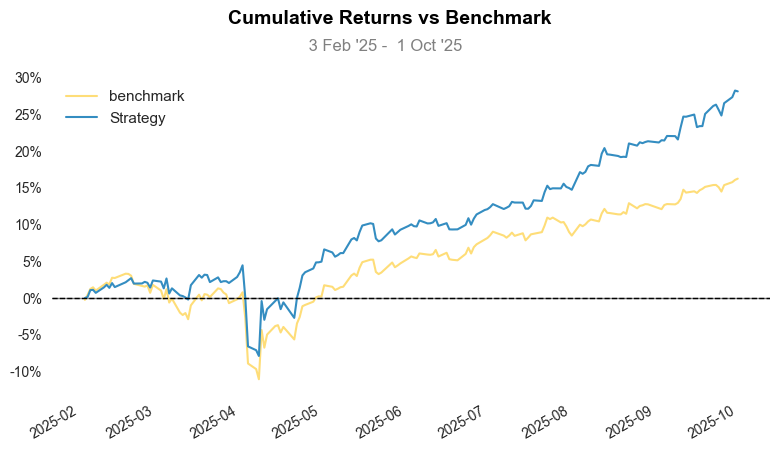

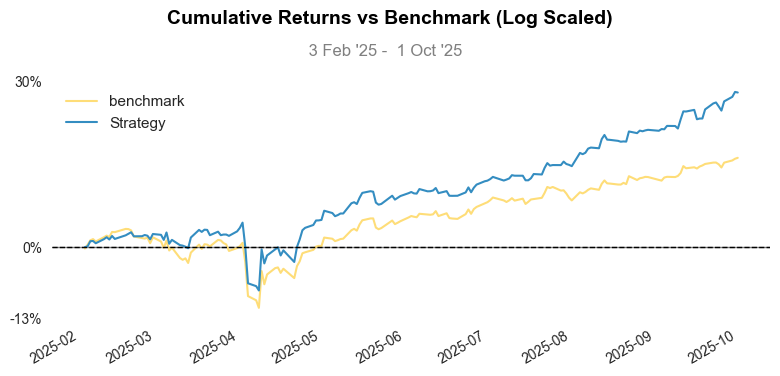

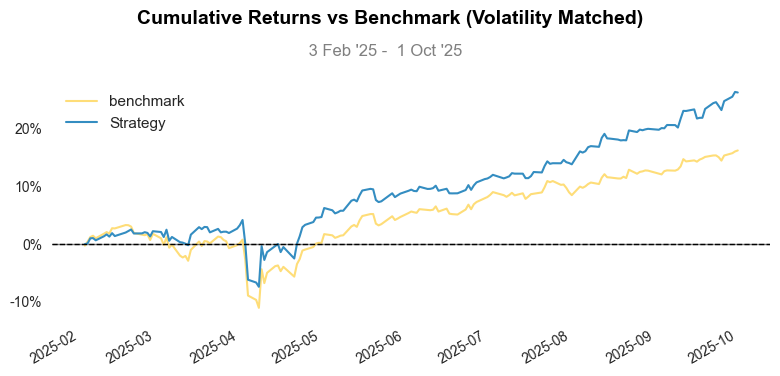

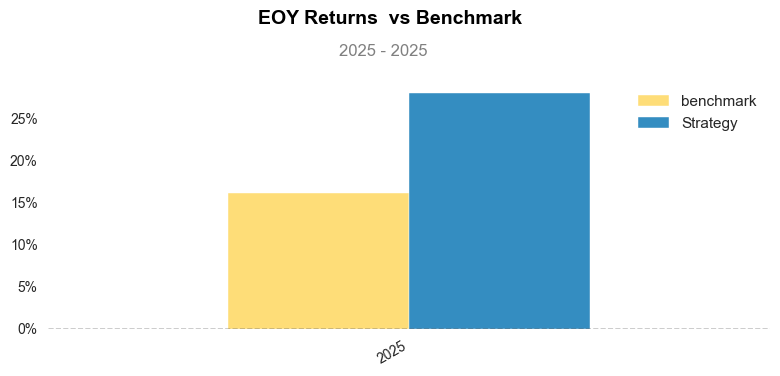

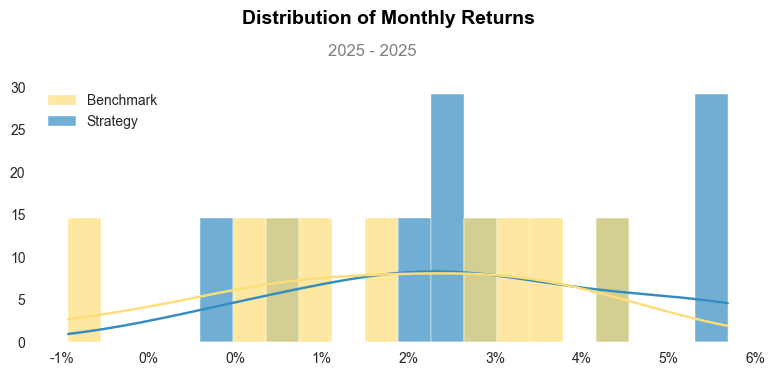

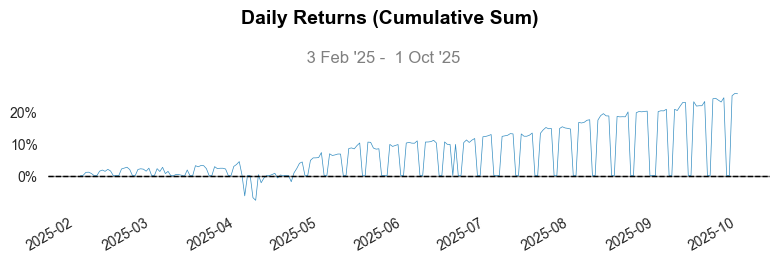

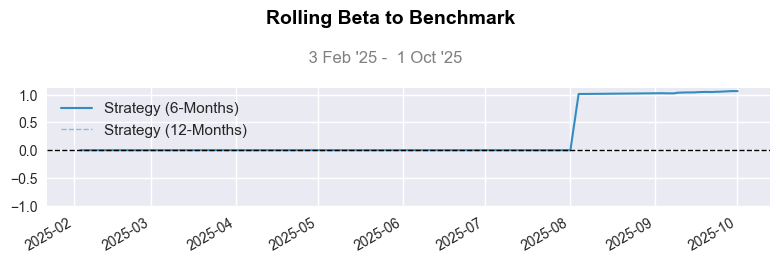

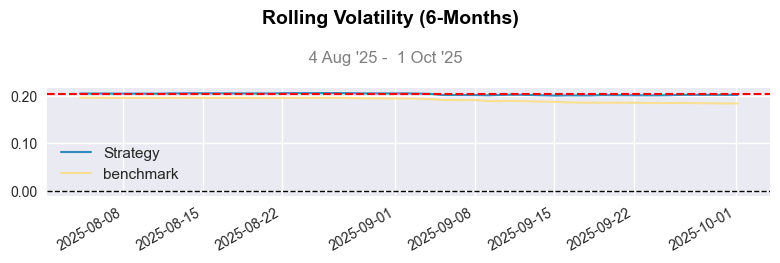

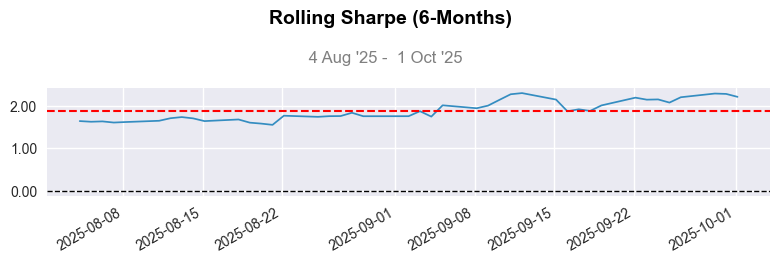

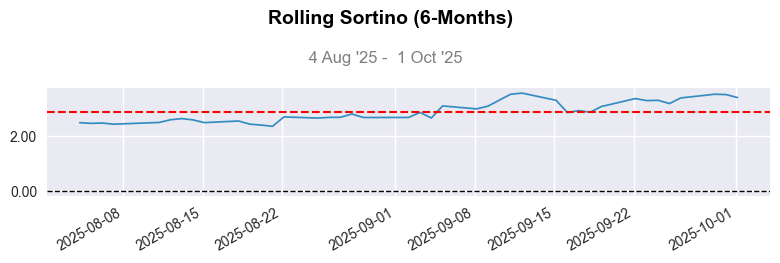

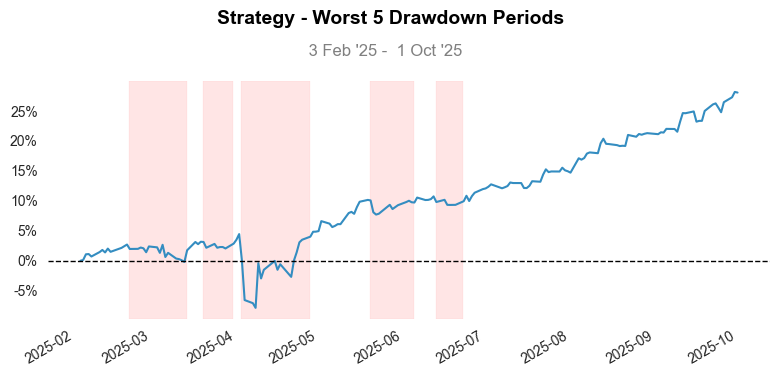

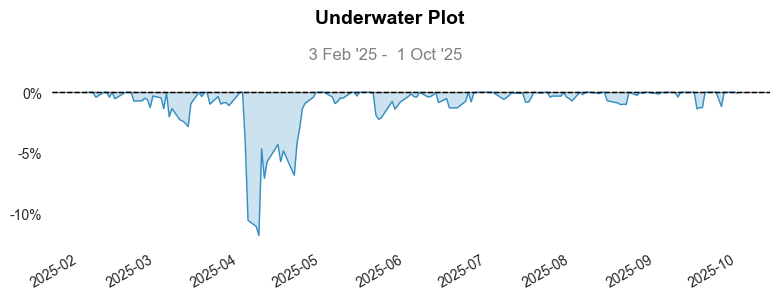

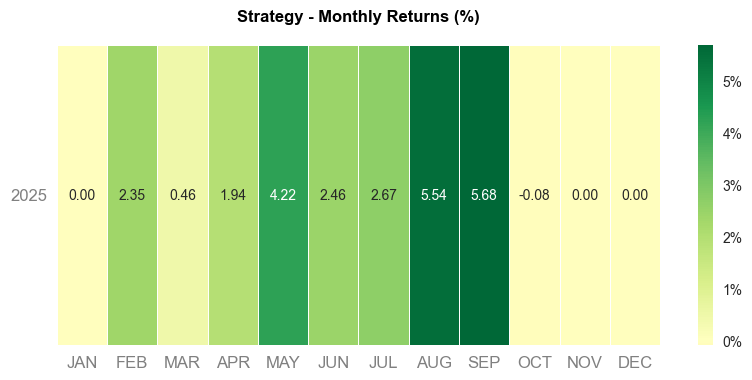

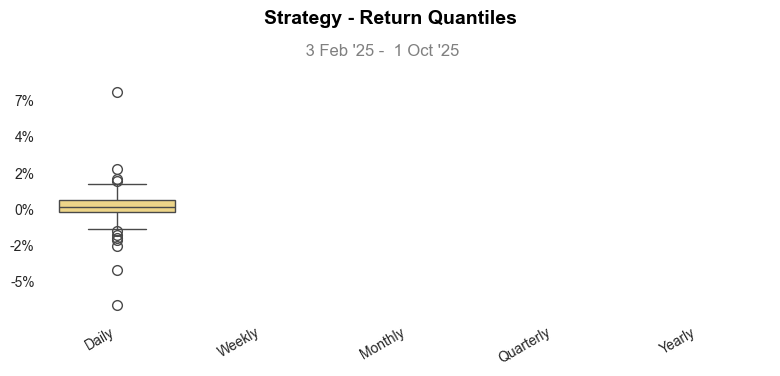

✓ QuantStats tear sheet generated. For the full HTML, open: tearsheet_sector_strategy.html


In [130]:
# === QuantStats tear sheet ===
# pip install if needed (uncomment next line if quantstats isn't installed)
# !pip install --quiet quantstats

import quantstats as qs

# ensure datetime index
strat_ret.index = pd.DatetimeIndex(strat_ret.index)
bench_ret.index = pd.DatetimeIndex(bench_ret.index)

# Option A: full HTML report file (saves to working directory)
qs.reports.html(
    strat_ret,
    benchmark=bench_ret,
    title="Sector Next-Month Strategy (Model = Best GRU/LSTM, Long-Only)",
    output="tearsheet_sector_strategy.html",
    figfmt="png"
)

# Option B: show key plots & stats inline (not saved)
qs.reports.full(
    strat_ret,
    benchmark=bench_ret,
    title="Sector Next-Month Strategy (Model = Best GRU/LSTM, Long-Only)",
    display=True,  # show in notebook
    output=None
)

print("✓ QuantStats tear sheet generated. For the full HTML, open: tearsheet_sector_strategy.html")